## 1. Import Library

In [2]:
import time
import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu


## 2. Setup Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Menggunakan device:", device)


Menggunakan device: cpu


## 3. Dataset Fashion-MNIST

Fashion-MNIST terdiri dari 60.000 gambar training dan 10.000 gambar test,
masing-masing berukuran 28x28 piksel grayscale, terbagi dalam 10 kelas pakaian.

Kita akan:
- Melakukan normalisasi
- Membagi data training menjadi *train* (90%) dan *validation* (10%)
- Membuat `DataLoader` untuk train, validation, dan test


In [4]:
BATCH_SIZE = 128

# Normalisasi standar untuk Fashion-MNIST (mean & std dari data grayscale)
MEAN, STD = (0.2860,), (0.3530,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Download otomatis ke folder ./data
train_full_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Split train -> train (90%) & validation (10%)
val_ratio = 0.1
val_size = int(len(train_full_dataset) * val_ratio)
train_size = len(train_full_dataset) - val_size

train_dataset, val_dataset = random_split(
    train_full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Jumlah data train      : {len(train_dataset)}")
print(f"Jumlah data validation : {len(val_dataset)}")
print(f"Jumlah data test       : {len(test_dataset)}")


100.0%
100.0%
100.0%
100.0%


Jumlah data train      : 54000
Jumlah data validation : 6000
Jumlah data test       : 10000


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


### 3.1 Visualisasi Contoh Data

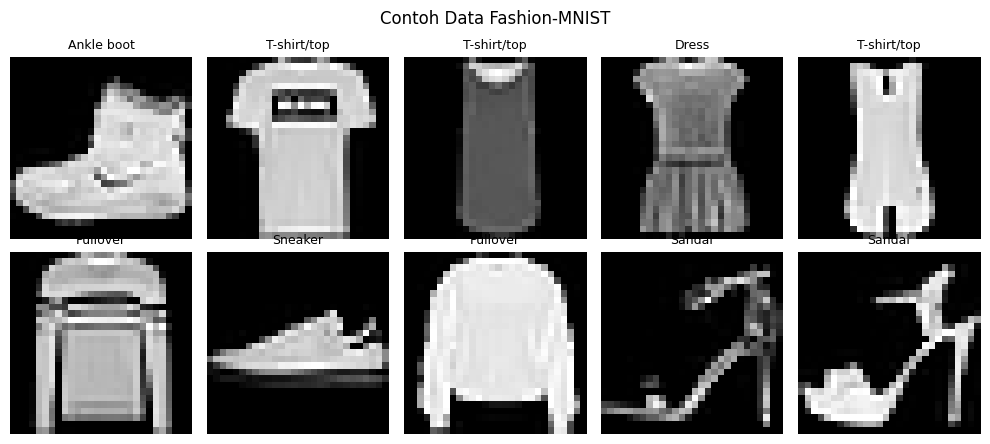

In [6]:
def denormalize(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    img, label = train_full_dataset[i]
    img = denormalize(img).squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Contoh Data Fashion-MNIST")
plt.tight_layout()
plt.show()


## 4. Definisi Model

### Model A — SimpleCNN
Arsitektur CNN sederhana: 2 blok Conv-ReLU-Pool, lalu Fully Connected.

### Model B — DeeperCNN
Arsitektur CNN yang lebih dalam dengan Batch Normalization dan Dropout,
digunakan sebagai pembanding performa terhadap Model A.


In [7]:
class SimpleCNN(nn.Module):
    """CNN sederhana: 2 conv block + 1 fully connected hidden layer."""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 28x28x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14x32
        self.pool = nn.MaxPool2d(2, 2)                             # /2 tiap panggilan

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 14x14x16
        x = self.pool(F.relu(self.conv2(x)))   # -> 7x7x32
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class DeeperCNN(nn.Module):
    """CNN lebih dalam dengan BatchNorm & Dropout sebagai model pembanding."""
    def __init__(self, num_classes=10):
        super(DeeperCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # -> 14x14x32
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # -> 7x7x64
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


### 4.1 Fungsi Hitung Jumlah Parameter (`count_parameters`)

In [8]:
def count_parameters(model):
    """Menghitung jumlah total parameter (trainable) sebuah model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model_a_tmp = SimpleCNN().to(device)
model_b_tmp = DeeperCNN().to(device)

total_a, trainable_a = count_parameters(model_a_tmp)
total_b, trainable_b = count_parameters(model_b_tmp)

print(f"Model A (SimpleCNN) -> total params: {total_a:,} | trainable: {trainable_a:,}")
print(f"Model B (DeeperCNN) -> total params: {total_b:,} | trainable: {trainable_b:,}")

del model_a_tmp, model_b_tmp


Model A (SimpleCNN) -> total params: 206,922 | trainable: 206,922
Model B (DeeperCNN) -> total params: 871,018 | trainable: 871,018


## 5. Fungsi Training & Evaluasi

Fungsi berikut menjalankan satu epoch training/evaluasi dan mengembalikan
*loss* rata-rata serta akurasi.


In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Menjalankan satu epoch. Jika optimizer diberikan -> mode training,
    jika None -> mode evaluasi (validation/test)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    torch.set_grad_enabled(is_train)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    torch.set_grad_enabled(True)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, model_name="Model"):
    """Melatih model, mencatat history loss/acc, dan mengukur waktu training total."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start_time = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    total_time = time.time() - start_time
    print(f"\nWaktu training total [{model_name}]: {total_time:.2f} detik "
          f"({total_time/60:.2f} menit)")

    return history, total_time


## 6. Training Model A — SimpleCNN

In [10]:
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

model_a = SimpleCNN(num_classes=10).to(device)
history_a, time_a = train_model(
    model_a, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, model_name="SimpleCNN"
)


[SimpleCNN] Epoch 01/10 | train_loss=0.5653 train_acc=0.7968 | val_loss=0.3883 val_acc=0.8547
[SimpleCNN] Epoch 02/10 | train_loss=0.3477 train_acc=0.8734 | val_loss=0.2961 val_acc=0.8902
[SimpleCNN] Epoch 03/10 | train_loss=0.3012 train_acc=0.8902 | val_loss=0.2682 val_acc=0.9005
[SimpleCNN] Epoch 04/10 | train_loss=0.2747 train_acc=0.8993 | val_loss=0.2640 val_acc=0.9025
[SimpleCNN] Epoch 05/10 | train_loss=0.2545 train_acc=0.9053 | val_loss=0.2503 val_acc=0.9040
[SimpleCNN] Epoch 06/10 | train_loss=0.2337 train_acc=0.9144 | val_loss=0.2345 val_acc=0.9138
[SimpleCNN] Epoch 07/10 | train_loss=0.2224 train_acc=0.9179 | val_loss=0.2287 val_acc=0.9148
[SimpleCNN] Epoch 08/10 | train_loss=0.2088 train_acc=0.9227 | val_loss=0.2285 val_acc=0.9138
[SimpleCNN] Epoch 09/10 | train_loss=0.1934 train_acc=0.9280 | val_loss=0.2252 val_acc=0.9140
[SimpleCNN] Epoch 10/10 | train_loss=0.1845 train_acc=0.9311 | val_loss=0.2246 val_acc=0.9183

Waktu training total [SimpleCNN]: 557.12 detik (9.29 menit)

## 7. Training Model B — DeeperCNN

In [11]:
model_b = DeeperCNN(num_classes=10).to(device)
history_b, time_b = train_model(
    model_b, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, model_name="DeeperCNN"
)


[DeeperCNN] Epoch 01/10 | train_loss=0.4210 train_acc=0.8475 | val_loss=0.2958 val_acc=0.8932
[DeeperCNN] Epoch 02/10 | train_loss=0.2700 train_acc=0.9021 | val_loss=0.2343 val_acc=0.9148
[DeeperCNN] Epoch 03/10 | train_loss=0.2344 train_acc=0.9155 | val_loss=0.2195 val_acc=0.9187
[DeeperCNN] Epoch 04/10 | train_loss=0.2068 train_acc=0.9232 | val_loss=0.2080 val_acc=0.9245
[DeeperCNN] Epoch 05/10 | train_loss=0.1854 train_acc=0.9311 | val_loss=0.2089 val_acc=0.9263
[DeeperCNN] Epoch 06/10 | train_loss=0.1694 train_acc=0.9382 | val_loss=0.1939 val_acc=0.9298
[DeeperCNN] Epoch 07/10 | train_loss=0.1498 train_acc=0.9455 | val_loss=0.2038 val_acc=0.9258
[DeeperCNN] Epoch 08/10 | train_loss=0.1385 train_acc=0.9481 | val_loss=0.1809 val_acc=0.9393
[DeeperCNN] Epoch 09/10 | train_loss=0.1230 train_acc=0.9542 | val_loss=0.1927 val_acc=0.9328
[DeeperCNN] Epoch 10/10 | train_loss=0.1113 train_acc=0.9590 | val_loss=0.2031 val_acc=0.9347

Waktu training total [DeeperCNN]: 1612.38 detik (26.87 meni

## 8. Kurva Training & Validation Loss / Accuracy

Berikut kurva *loss* dan *accuracy* per epoch untuk masing-masing model.


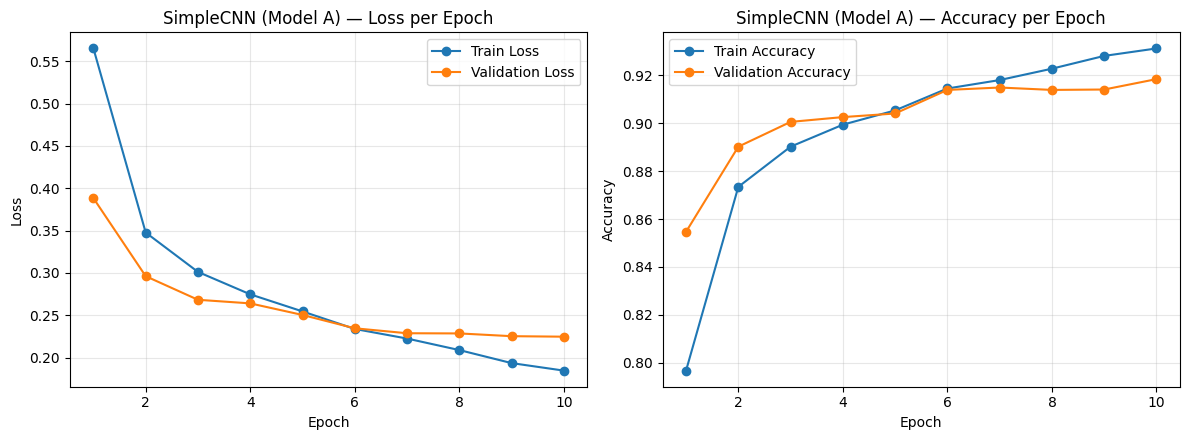

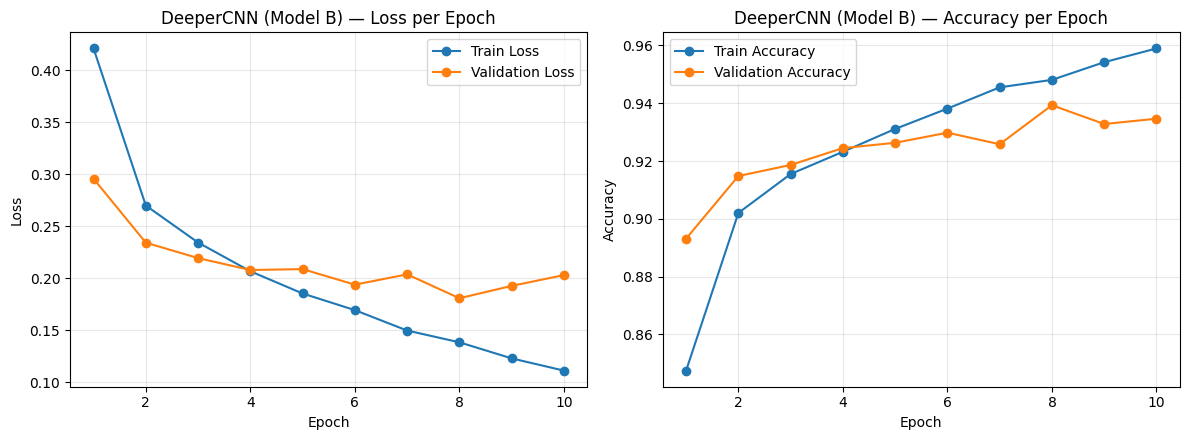

In [12]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Loss
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    axes[0].set_title(f"{model_name} — Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
    axes[1].set_title(f"{model_name} — Accuracy per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_a, "SimpleCNN (Model A)")
plot_history(history_b, "DeeperCNN (Model B)")


### 8.1 Perbandingan Langsung Kedua Model

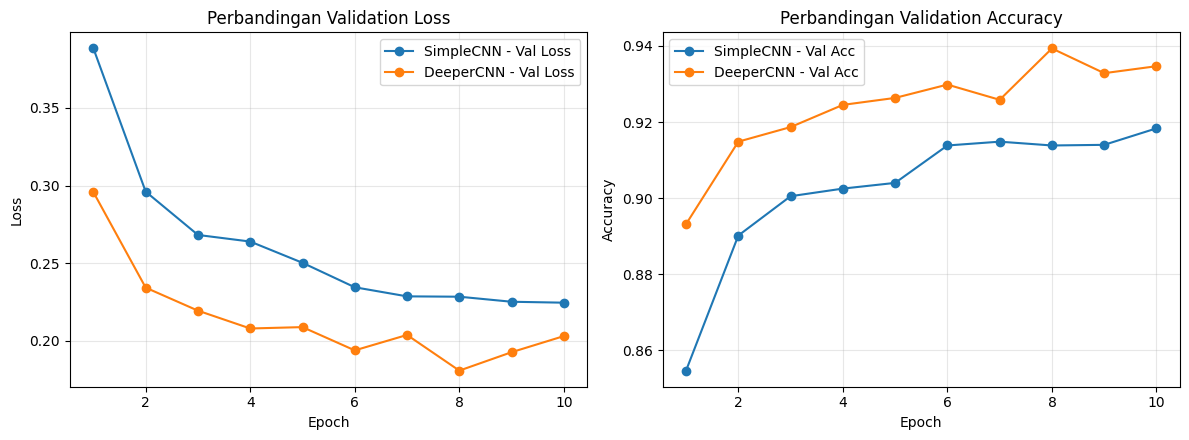

In [13]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs, history_a["val_loss"], marker="o", label="SimpleCNN - Val Loss")
axes[0].plot(epochs, history_b["val_loss"], marker="o", label="DeeperCNN - Val Loss")
axes[0].set_title("Perbandingan Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_a["val_acc"], marker="o", label="SimpleCNN - Val Acc")
axes[1].plot(epochs, history_b["val_acc"], marker="o", label="DeeperCNN - Val Acc")
axes[1].set_title("Perbandingan Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Evaluasi pada Test Set

Menghitung akurasi akhir pada test set serta mengumpulkan prediksi
untuk keperluan confusion matrix.


In [14]:
def evaluate_on_test(model, test_loader, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    model.eval()

    all_preds, all_labels = [], []
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc = correct / total
    print(f"[{model_name}] Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    return test_loss, test_acc, np.array(all_labels), np.array(all_preds)


test_loss_a, test_acc_a, y_true_a, y_pred_a = evaluate_on_test(model_a, test_loader, "SimpleCNN")
test_loss_b, test_acc_b, y_true_b, y_pred_b = evaluate_on_test(model_b, test_loader, "DeeperCNN")


[SimpleCNN] Test Loss: 0.2518 | Test Accuracy: 0.9120
[DeeperCNN] Test Loss: 0.2252 | Test Accuracy: 0.9308


### 9.1 Confusion Matrix — Model A (SimpleCNN)

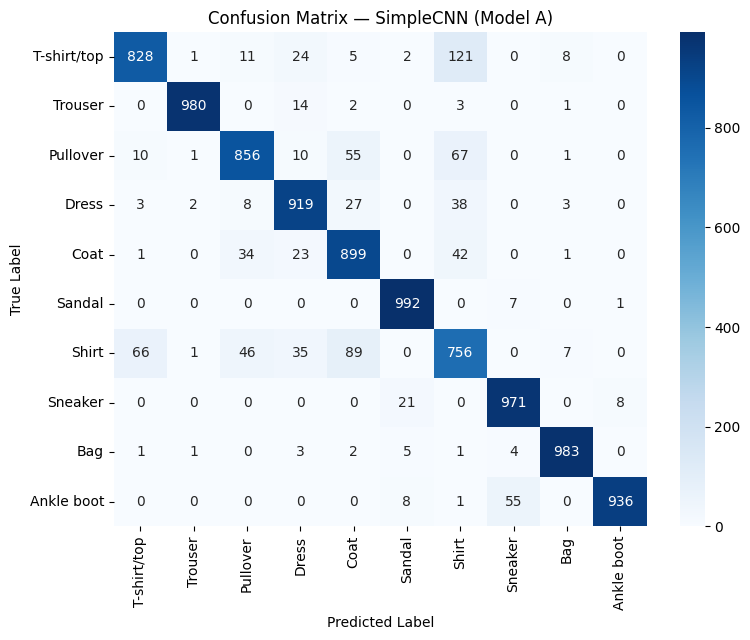

              precision    recall  f1-score   support

 T-shirt/top       0.91      0.83      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.86      0.88      1000
       Dress       0.89      0.92      0.91      1000
        Coat       0.83      0.90      0.86      1000
      Sandal       0.96      0.99      0.98      1000
       Shirt       0.73      0.76      0.75      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    return cm

cm_a = plot_confusion_matrix(y_true_a, y_pred_a, CLASS_NAMES, "SimpleCNN (Model A)")
print(classification_report(y_true_a, y_pred_a, target_names=CLASS_NAMES))


### 9.2 Confusion Matrix — Model B (DeeperCNN)

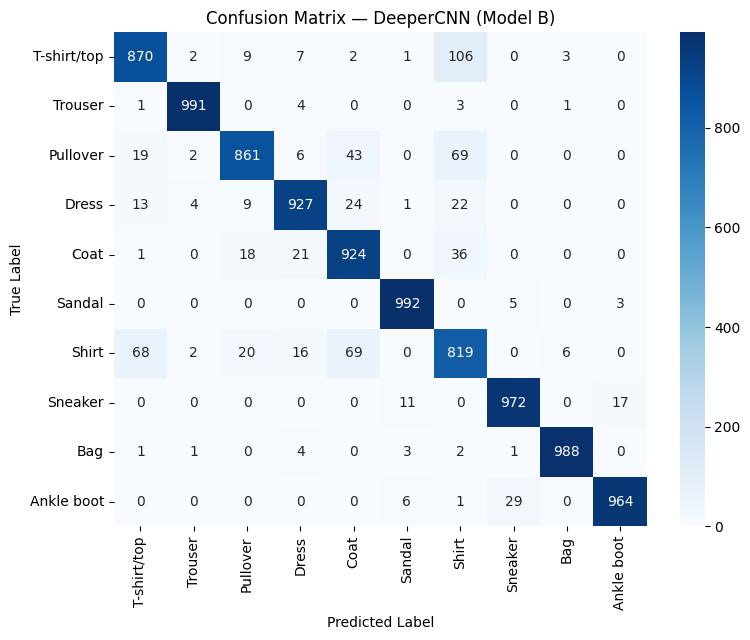

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.87      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.94      0.86      0.90      1000
       Dress       0.94      0.93      0.93      1000
        Coat       0.87      0.92      0.90      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.77      0.82      0.80      1000
     Sneaker       0.97      0.97      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [16]:
cm_b = plot_confusion_matrix(y_true_b, y_pred_b, CLASS_NAMES, "DeeperCNN (Model B)")
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))


## 10. Ringkasan Perbandingan Kedua Model

Tabel ringkasan berisi:
- Jumlah total parameter
- Waktu training total (detik & menit)
- Akurasi akhir pada test set


In [17]:
import pandas as pd

summary_df = pd.DataFrame({
    "Model": ["SimpleCNN (A)", "DeeperCNN (B)"],
    "Total Parameters": [f"{total_a:,}", f"{total_b:,}"],
    "Training Time (s)": [f"{time_a:.2f}", f"{time_b:.2f}"],
    "Training Time (min)": [f"{time_a/60:.2f}", f"{time_b/60:.2f}"],
    "Test Loss": [f"{test_loss_a:.4f}", f"{test_loss_b:.4f}"],
    "Test Accuracy": [f"{test_acc_a:.4f}", f"{test_acc_b:.4f}"],
})

summary_df


,Model,Total Parameters,Training Time (s),Training Time (min),Test Loss,Test Accuracy
0,SimpleCNN (A),"206,922",557.12,9.29,0.2518,0.9120
1,DeeperCNN (B),"871,018",1612.38,26.87,0.2252,0.9308


## 11. Kesimpulan

Isi bagian ini setelah menjalankan notebook, misalnya:
- Model mana yang memiliki akurasi test lebih tinggi?
- Apakah model dengan parameter lebih banyak (DeeperCNN) sepadan dengan
  peningkatan akurasi dibanding waktu training yang dibutuhkan?
- Apakah ada indikasi overfitting (train acc jauh lebih tinggi dari val acc)?
- Kelas mana yang paling sering tertukar berdasarkan confusion matrix
  (misalnya *Shirt* vs *T-shirt/top* vs *Coat* yang secara visual mirip)?
